# Notebook 02: Exploratory Data Analysis (EDA)

This notebook explores the cleaned county-level dataset to understand patterns, relationships, and trends in socioeconomic indicators.

The goal of this analysis is to:
- Understand the distribution of key variables such as income, poverty, unemployment, education, and housing
- Identify relationships between these variables
- Explore patterns in economic risk across counties
- Support the research questions through visual analysis

In [2]:
# Import required libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

## Load Cleaned County Dataset

In this step, the final cleaned dataset created in Notebook 01 is loaded.

This dataset contains county-level socioeconomic indicators including income, poverty rate, unemployment rate, education level, and housing characteristics.

Each row represents one U.S. county, and this dataset will be used for exploratory data analysis to identify patterns and relationships.

In [4]:
# Load cleaned dataset
df = pd.read_csv("county_master.csv")

# Check dataset shape
print("Dataset shape:", df.shape)

# Preview first few rows
df.head()

Dataset shape: (3222, 9)


,county_fips,county_name,total_population,median_household_income,poverty_rate,unemployment_rate,homeownership_rate,renter_rate,bachelors_or_higher_pct
0,1001,"Autauga County, Alabama",59947,72481.0,0.112895,0.022899,0.770607,0.229393,0.291385
1,1003,"Baldwin County, Alabama",246989,78775.0,0.100927,0.030107,0.776036,0.223964,0.336895
2,1005,"Barbour County, Alabama",24643,46042.0,0.213826,0.077736,0.682406,0.317594,0.106273
3,1007,"Bibb County, Alabama",22130,52541.0,0.224570,0.120808,0.791796,0.208204,0.117256
4,1009,"Blount County, Alabama",59518,64190.0,0.128601,0.049971,0.809829,0.190171,0.158182


## Dataset Structure and Data Types

This step examines the structure of the dataset, including column names, data types, and non-null counts.

This helps verify that all variables are correctly formatted and that there are no major missing data issues before proceeding with analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3222 entries, 0 to 3221
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county_fips              3222 non-null   int64  
 1   county_name              3222 non-null   object 
 2   total_population         3222 non-null   int64  
 3   median_household_income  3222 non-null   float64
 4   poverty_rate             3222 non-null   float64
 5   unemployment_rate        3222 non-null   float64
 6   homeownership_rate       3222 non-null   float64
 7   renter_rate              3222 non-null   float64
 8   bachelors_or_higher_pct  3222 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 226.7+ KB


---
## Distribution of Key Economic Indicators

This section explores the distribution of key socioeconomic variables across U.S. counties.

Understanding these distributions helps identify patterns such as inequality, skewness, and variation in economic conditions.

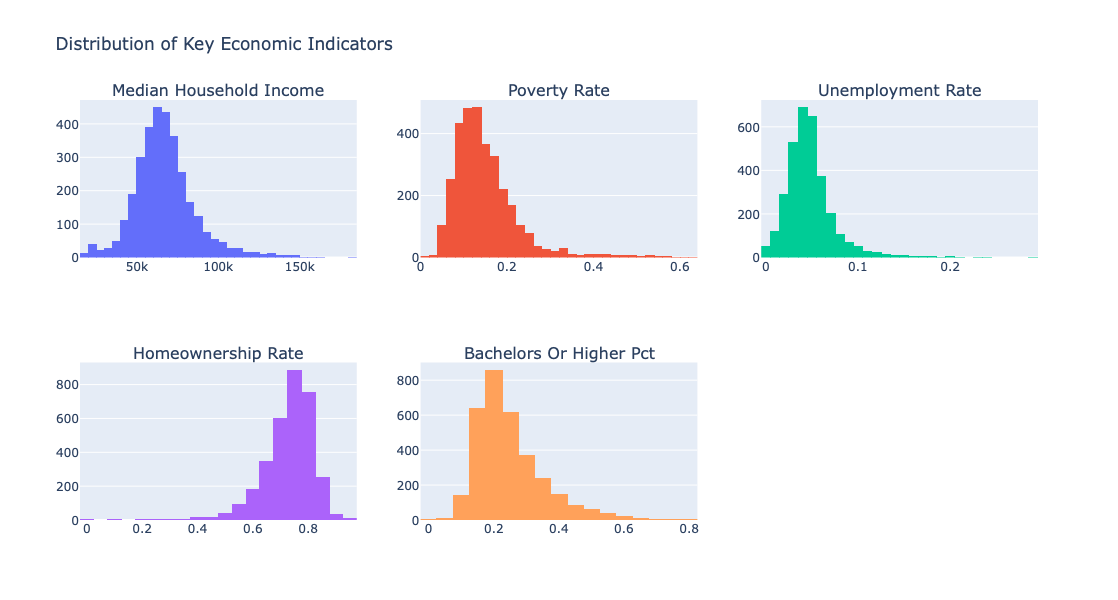

In [8]:
import plotly.subplots as sp
import plotly.graph_objects as go

# -------------------------------------------------------
# Distribution of Key Economic Indicators (Interactive)
# -------------------------------------------------------

features = [
    "median_household_income",
    "poverty_rate",
    "unemployment_rate",
    "homeownership_rate",
    "bachelors_or_higher_pct"
]

# Create subplot grid (2 rows, 3 columns)
fig = sp.make_subplots(
    rows=2,
    cols=3,
    subplot_titles=[col.replace("_", " ").title() for col in features]
)

# Add histograms
for i, col in enumerate(features):
    row = (i // 3) + 1
    col_pos = (i % 3) + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=40,
            name=col,
            showlegend=False
        ),
        row=row,
        col=col_pos
    )

# Layout adjustments
fig.update_layout(
    height=600,
    width=1000,
    title_text="Distribution of Key Economic Indicators"
)

fig.show()

### Observations

The distributions of key socioeconomic indicators reveal important patterns across U.S. counties:

- **Median Household Income:** The distribution is slightly right-skewed, with most counties clustered between 50,000 and 80,000. A smaller number of counties have significantly higher incomes, indicating income inequality.

- **Poverty Rate:** The majority of counties fall between 10% and 20%, but there are counties with much higher poverty levels, showing significant economic disparity.

- **Unemployment Rate:** Most counties have relatively low unemployment rates (around 3%–6%), with a few counties showing higher unemployment, indicating localized economic challenges.

- **Homeownership Rate:** The distribution is left-skewed, with most counties having high homeownership rates (around 65%–80%), suggesting relative housing stability across many regions.

- **Education Level (Bachelor’s or Higher):** The distribution is right-skewed, with most counties having lower percentages of highly educated individuals, while a smaller number of counties have significantly higher education levels.

Overall, these distributions show substantial variation across counties in key socioeconomic factors, highlighting differences in economic conditions and supporting the need for a combined economic risk measure.

This analysis addresses:

**What are the distributions and patterns of key socioeconomic indicators across U.S. counties?**

---
## Correlation Between Economic Indicators

This section examines the relationships between key socioeconomic variables using a correlation heatmap.

Correlation values range from -1 to 1:
- Positive values indicate variables increase together
- Negative values indicate an inverse relationship

This helps identify which factors are most strongly associated with economic conditions.

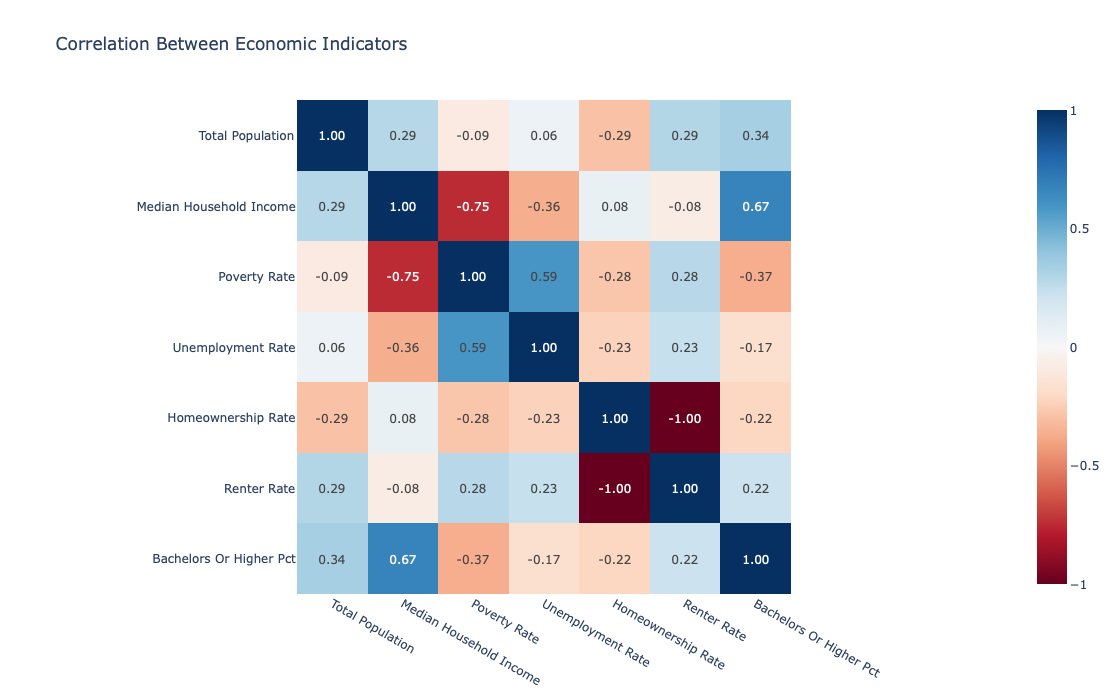

In [11]:
# -------------------------------------------------------
# Correlation Heatmap (Interactive - Plotly)
# -------------------------------------------------------

import plotly.express as px

# Compute correlation matrix
corr = df.drop(columns=["county_fips", "county_name"]).corr()

# Clean column names for better readability
corr.index = [col.replace("_", " ").title() for col in corr.index]
corr.columns = corr.index

# Create heatmap
fig = px.imshow(
    corr,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title="Correlation Between Economic Indicators"
)

# Layout adjustments
fig.update_layout(
    width=800,
    height=700
)

fig.show()

### Observations

The correlation heatmap reveals several strong and meaningful relationships between socioeconomic indicators:

- **Income and Poverty (-0.75):** There is a strong negative correlation, indicating that counties with higher median household income tend to have significantly lower poverty rates.

- **Income and Education (0.67):** A strong positive correlation shows that counties with higher levels of education tend to have higher income levels.

- **Poverty and Unemployment (0.59):** A moderate positive correlation suggests that higher unemployment is associated with higher poverty levels.

- **Poverty and Education (-0.37):** There is a negative relationship, indicating that higher education levels are associated with lower poverty.

- **Homeownership and Renter Rate (-1.00):** A perfect negative correlation exists, which is expected since these two variables are complementary.

- **Population:** Shows relatively weak correlations with most variables, suggesting that county size alone does not strongly determine economic conditions.

Overall, these relationships confirm that economic indicators are interconnected, especially income, education, and poverty, and should be analyzed together when assessing economic risk.

This analysis addresses:

**How do key socioeconomic indicators (income, poverty, unemployment, education, and homeownership) influence a county’s economic risk?**

---

## Income vs Poverty Relationship

This plot examines the relationship between median household income and poverty rate across U.S. counties.

Understanding this relationship helps identify how income levels influence economic hardship.

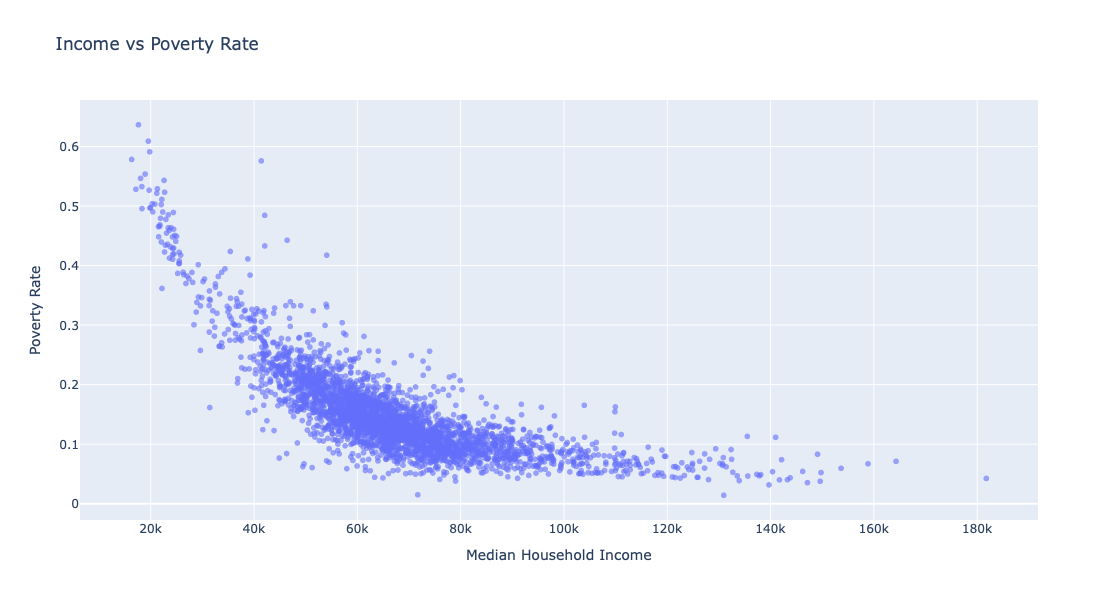

In [14]:
# -------------------------------------------------------
# Income vs Poverty Relationship (Interactive - Plotly)
# -------------------------------------------------------

import plotly.express as px

fig = px.scatter(
    df,
    x="median_household_income",
    y="poverty_rate",
    title="Income vs Poverty Rate",
    opacity=0.6,
    hover_data=["county_name"],
    labels={
        "median_household_income": "Median Household Income",
        "poverty_rate": "Poverty Rate"
    }
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

### Observations

There is a strong negative relationship between median household income and poverty rate.

As income increases, poverty rate decreases sharply, especially in lower-income counties. The relationship appears nonlinear, with a steep decline in poverty at lower income levels and a gradual flattening at higher income levels.

Most counties are concentrated between $40,000 and $80,000 in income, with corresponding poverty rates between 10% and 25%. Counties with very low income (below $40,000) tend to have significantly higher poverty rates, often exceeding 30%.

At higher income levels (above $100,000), poverty rates are consistently low and stable.

This pattern highlights that income is one of the strongest drivers of economic conditions across counties.

This analysis addresses:

**How do key socioeconomic indicators influence a county’s economic risk?**

---
## Education vs Income Relationship

This plot examines how education levels relate to median household income across counties.

Education is an important factor influencing economic opportunities and long-term income levels.

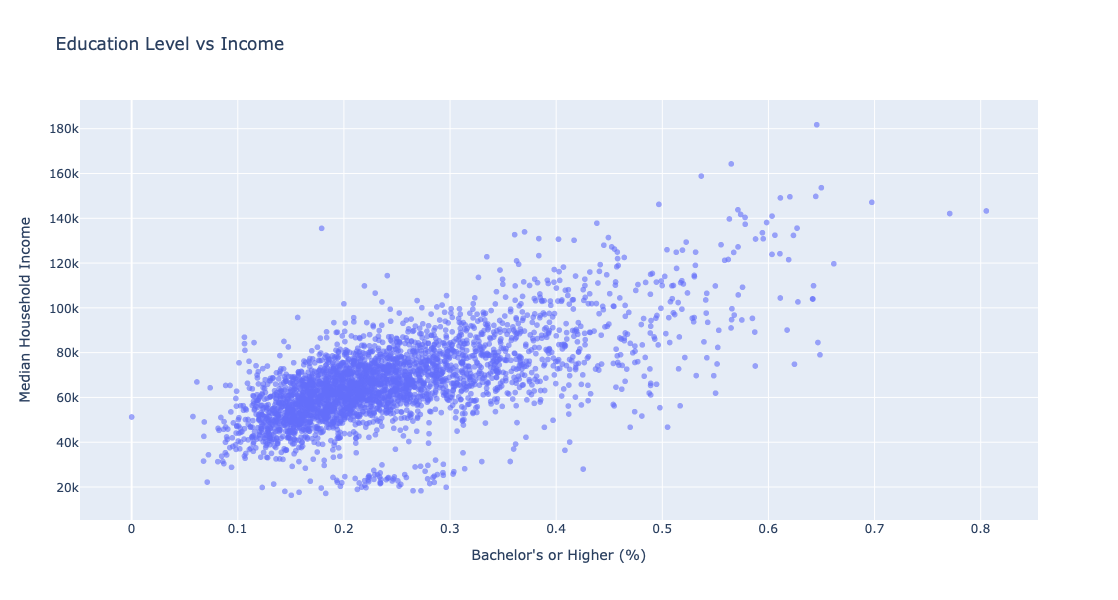

In [17]:
# -------------------------------------------------------
# Education vs Income Relationship (Interactive - Plotly)
# -------------------------------------------------------

import plotly.express as px

fig = px.scatter(
    df,
    x="bachelors_or_higher_pct",
    y="median_household_income",
    title="Education Level vs Income",
    opacity=0.6,
    hover_data=["county_name"],
    labels={
        "bachelors_or_higher_pct": "Bachelor's or Higher (%)",
        "median_household_income": "Median Household Income"
    }
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

### Observations

There is a clear positive relationship between education level and median household income.

Counties with a higher percentage of individuals holding a bachelor’s degree or higher tend to have significantly higher income levels. As education increases, income rises steadily, indicating a strong upward trend.

Most counties are concentrated between 10% and 40% education levels, with corresponding income levels between $50,000 and $90,000. Counties with very high education levels (above 50%) tend to have much higher incomes, often exceeding $100,000.

There is some spread in the data, especially at mid-level education ranges, suggesting that while education is a strong driver of income, other factors also influence economic outcomes.

Overall, this confirms that education plays a critical role in determining economic prosperity across counties.

This analysis addresses:

**How do key socioeconomic indicators influence a county’s economic risk?**

---
## Poverty vs Unemployment Relationship

This plot examines how unemployment levels relate to poverty across counties.

Unemployment is a key indicator of economic health and is expected to influence poverty levels.

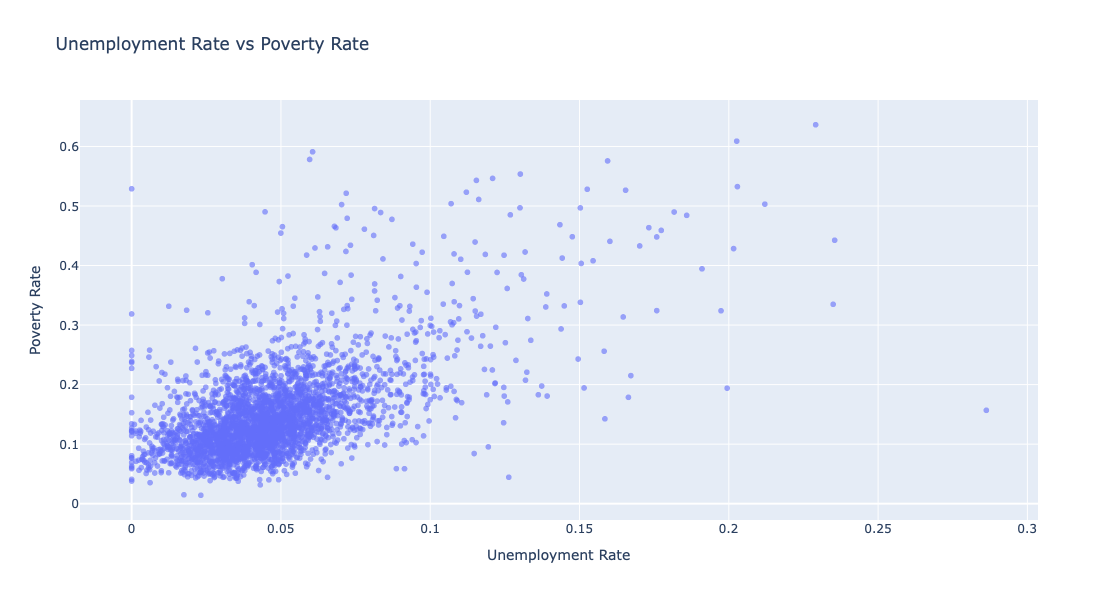

In [20]:
# -------------------------------------------------------
# Unemployment vs Poverty Relationship (Interactive - Plotly)
# -------------------------------------------------------

import plotly.express as px

fig = px.scatter(
    df,
    x="unemployment_rate",
    y="poverty_rate",
    title="Unemployment Rate vs Poverty Rate",
    opacity=0.6,
    hover_data=["county_name"],
    labels={
        "unemployment_rate": "Unemployment Rate",
        "poverty_rate": "Poverty Rate"
    }
)

fig.update_layout(
    width=800,
    height=600
)

fig.show()

### Observations

There is a positive relationship between unemployment rate and poverty rate, although the relationship is more dispersed compared to other variables.

Counties with higher unemployment rates tend to have higher poverty levels, but the relationship is not perfectly linear. Most counties are concentrated at lower unemployment levels (below 10%) with poverty rates between 10% and 25%.

As unemployment increases, poverty generally rises, but there is noticeable variability, indicating that unemployment alone does not fully explain poverty levels.

Some counties with moderate unemployment still exhibit high poverty, suggesting that additional factors such as education, income, and regional conditions also play a role.

Overall, this indicates that unemployment contributes to economic hardship, but it is one of several interacting factors.

This analysis addresses:

**How do key socioeconomic indicators influence a county’s economic risk?**

---
## Final EDA Summary

The exploratory data analysis reveals significant variation in economic conditions across U.S. counties.

Key insights include:

- A strong negative relationship between income and poverty
- A strong positive relationship between education and income
- A moderate positive relationship between unemployment and poverty
- Significant variation across all socioeconomic indicators

These findings show that economic conditions are influenced by multiple interconnected factors, supporting the need for a combined economic risk score in further analysis.